<a href="https://colab.research.google.com/github/ryoder96/clinical-nlp-uncertainty/blob/main/NLP_Project_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## This Notebook explores the Kaggle dataset mtsamples
More info tbd

In [ ]:
# In Colab
!pip install kaggle
!kaggle datasets download -d tboyle10/medicaltranscriptions

Dataset URL: https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions
License(s): CC0-1.0
100% 4.85M/4.85M [00:01<00:00, 3.44MB/s]



In [ ]:
!unzip medicaltranscriptions.zip

Archive:  medicaltranscriptions.zip
  inflating: mtsamples.csv           


In [ ]:
# =============================================
# STEP 1: Load and inspect
# =============================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mtsamples.csv', index_col=0)

print(df.shape)
print(df.columns.tolist())
df.head(2)

(4999, 5)
['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."


In [ ]:
df.head()

,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


### Notes on step 1 cell:
* transcription = NLP input
* medical specialty = label

In [ ]:
# =============================================
# STEP 2: Missing values
# =============================================
print(df.isnull().sum())
print(f"\nMissing transcriptions: {df['transcription'].isnull().sum()}")
print(f"Missing specialties: {df['medical_specialty'].isnull().sum()}")

# Drop rows with missing transcription or specialty — unusable for us
df = df.dropna(subset=['transcription', 'medical_specialty'])
print(f"\nRows after dropping nulls: {len(df)}")

description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

Missing transcriptions: 33
Missing specialties: 0

Rows after dropping nulls: 4966


### Notes on Step 2 cell:
* 33 missing transcriptions - we'll drop those
* 1,068 missing keywords - don't care

medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    61
Psychiatry / Psychology            53
Office Notes                       50
Podiatry                           47
Dermatology                        29
Dentistry                          27
Cosmetic / Plastic Surgery      

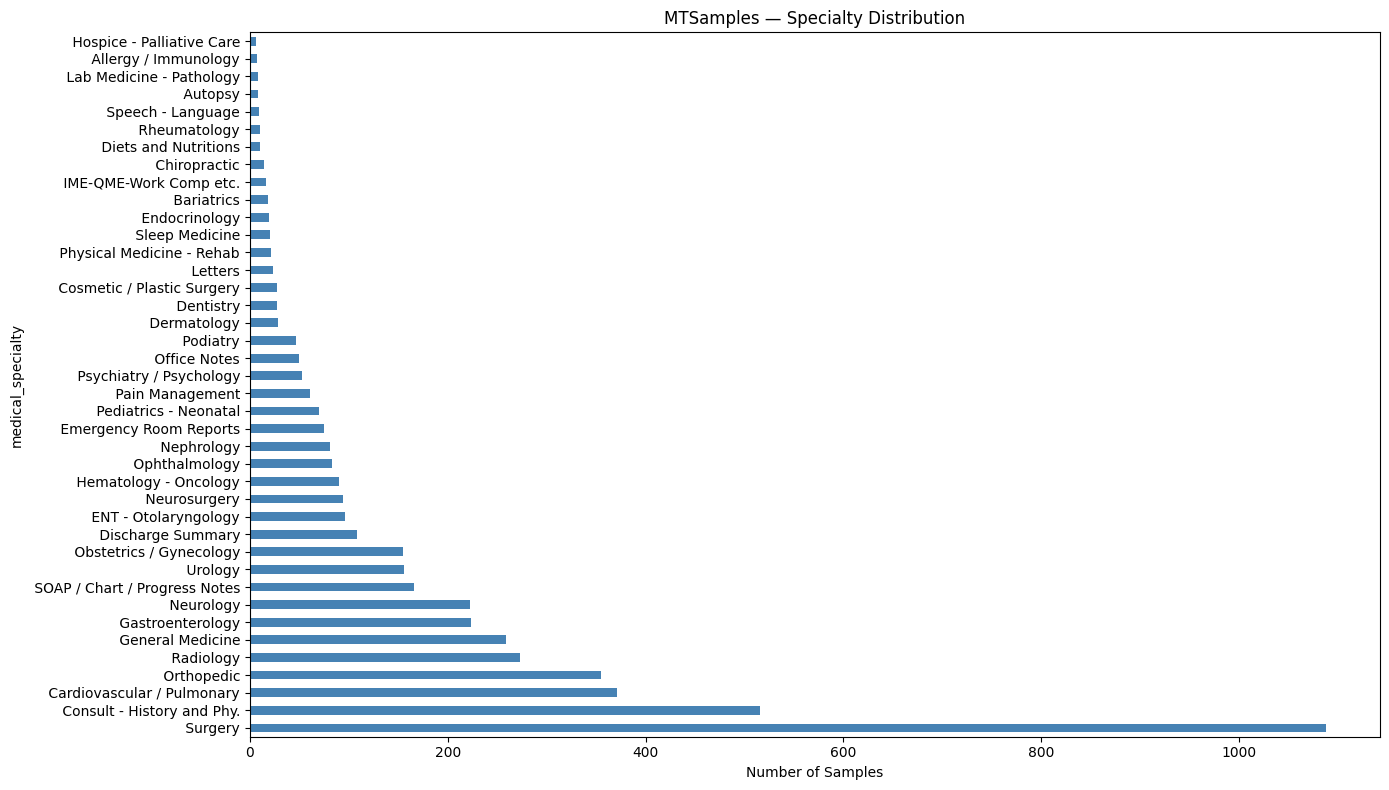

In [ ]:
# =============================================
# STEP 3: Class distribution — the critical one
# =============================================
specialty_counts = df['medical_specialty'].value_counts()
print(specialty_counts)
print(f"\nNumber of unique specialties: {df['medical_specialty'].nunique()}")
print(f"Classes with fewer than 50 samples: {(specialty_counts < 50).sum()}")
print(f"Classes with fewer than 20 samples: {(specialty_counts < 20).sum()}")

# Visualize
plt.figure(figsize=(14, 8))
specialty_counts.plot(kind='barh', color='steelblue')
plt.xlabel('Number of Samples')
plt.title('MTSamples — Specialty Distribution')
plt.tight_layout()
plt.show()

### Notes on Step 3 cell:
Drop:
* Consult
* SOAP
* Discharge summary
* Office notes
* Letters
* IME_QME-WORK Comp
* Lab medicine

Potential Drops due to Scarcity:
* Podiatry and below

In [ ]:
# =============================================
# STEP 3b: Drop categories we don't want
# =============================================
df['medical_specialty'] = df['medical_specialty'].str.strip()

# Now redo the drop
specialty_counts = df['medical_specialty'].value_counts()
small_classes = specialty_counts[specialty_counts < 30].index.tolist()

drop_labels = [
    'Consult - History and Phy.',
    'SOAP / Chart / Progress Notes',
    'Discharge Summary',
    'Office Notes',
    'Letters',
    'IME-QME-Work Comp etc.',
    'Lab Medicine - Pathology',
    'Autopsy',
    'Hospice - Palliative Care'
]

drop_all = list(set(drop_labels + small_classes))
df_clean = df[~df['medical_specialty'].isin(drop_all)].copy()

print(f"Rows remaining: {len(df_clean)}")
print(f"Specialties remaining: {df_clean['medical_specialty'].nunique()}")
print(df_clean['medical_specialty'].value_counts())

Rows remaining: 3854
Specialties remaining: 19
medical_specialty
Surgery                       1088
Cardiovascular / Pulmonary     371
Orthopedic                     355
Radiology                      273
General Medicine               259
Gastroenterology               224
Neurology                      223
Urology                        156
Obstetrics / Gynecology        155
ENT - Otolaryngology            96
Neurosurgery                    94
Hematology - Oncology           90
Ophthalmology                   83
Nephrology                      81
Emergency Room Reports          75
Pediatrics - Neonatal           70
Pain Management                 61
Psychiatry / Psychology         53
Podiatry                        47
Name: count, dtype: int64


### Notes on Cell 3b
* Surgery is overrepresented
* Options:
  * undersample surgery
  * use class weights during training

Note: clinical overlaps
* Surgery + Orthopedic + Neurosurgery — all cutting specialties, notes will bleed together
* Neurology + Neurosurgery — obvious overlap
* Cardiovascular/Pulmonary is already merged — interesting that whoever labeled this data combined them

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

count     500.00000
mean      795.17400
std       473.46296
min        16.00000
25%       441.25000
50%       716.50000
75%      1061.25000
max      3192.00000
Name: token_count, dtype: float64

Notes exceeding 512 tokens: 338 / 500
Notes exceeding 512 tokens: 67.6%


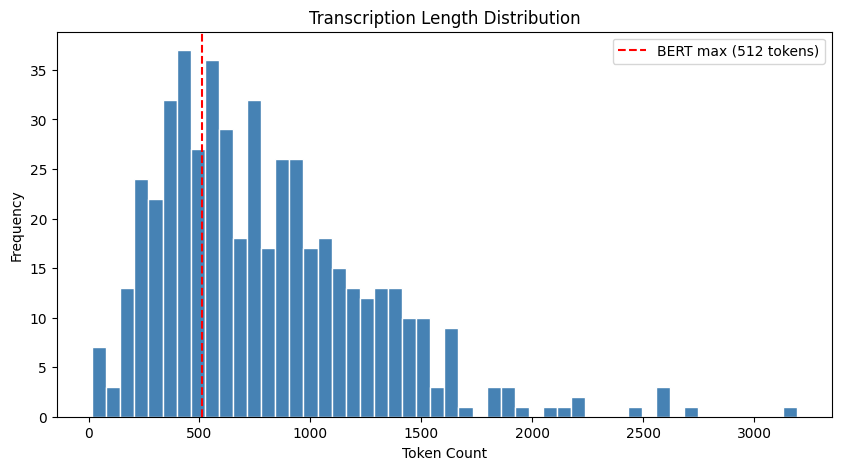

In [ ]:
# =============================================
# STEP 4: Transcription length — critical for BERT
# =============================================
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# Sample 500 rows for speed
sample = df.sample(500, random_state=42)
sample['token_count'] = sample['transcription'].apply(
    lambda x: len(tokenizer.encode(x, truncation=False))
)

print(sample['token_count'].describe())
print(f"\nNotes exceeding 512 tokens: {(sample['token_count'] > 512).sum()} / 500")
print(f"Notes exceeding 512 tokens: {(sample['token_count'] > 512).mean():.1%}")

plt.figure(figsize=(10, 5))
plt.hist(sample['token_count'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(512, color='red', linestyle='--', label='BERT max (512 tokens)')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title('Transcription Length Distribution')
plt.legend()
plt.show()

### Notes on step 4
* 67.6% of notes exceed 512 tokens
* Options:
  * Truncate
  * Concatenate description + transcription then truncate
  * use description field
  * chunk and pool
  * Don't use BERT at all! (longformer, but not clinical)

In [ ]:
# =============================================
# STEP 5: Text quality check
# =============================================

# Are notes actually clinical text or garbage?
print("--- 3 random transcriptions ---\n")
for _, row in df.sample(3, random_state=1).iterrows():
    print(f"SPECIALTY: {row['medical_specialty']}")
    print(f"TEXT: {row['transcription'][:300]}")
    print("-" * 60)

# Check for very short notes that might be useless
df['word_count'] = df['transcription'].apply(lambda x: len(str(x).split()))
print(f"\nNotes under 50 words: {(df['word_count'] < 50).sum()}")
print(df[df['word_count'] < 50][['medical_specialty', 'transcription']].head(5))

--- 3 random transcriptions ---

SPECIALTY: General Medicine
TEXT: HISTORY OF PRESENT ILLNESS:, The patient is a 71-year-old Caucasian female with a history of diabetes, osteoarthritis, atrial fibrillation, hypertension, asthma, obstructive sleep apnea on CPAP, diabetic foot ulcer, anemia and left lower extremity cellulitis. She was brought in by the EMS service to
------------------------------------------------------------
SPECIALTY: Obstetrics / Gynecology
TEXT: PREOPERATIVE DIAGNOSIS: , Postpartum hemorrhage.,POSTOPERATIVE DIAGNOSIS: , Postpartum hemorrhage.,PROCEDURE:,  Exam under anesthesia.  Removal of intrauterine clots.,ANESTHESIA: , Conscious sedation.,ESTIMATED BLOOD LOSS:,  Approximately 200 mL during the procedure, but at least 500 mL prior to tha
------------------------------------------------------------
SPECIALTY: Pediatrics - Neonatal
TEXT: HISTORY OF PRESENT ILLNESS: , This is a ** week gestational age ** delivered by ** at ** on **.  Gestational age was determined b

In [ ]:
df_clean['word_count'] = df_clean['transcription'].apply(lambda x: len(str(x).split()))
df_clean = df_clean[df_clean['word_count'] >= 50].copy()
print(f"Rows after dropping short notes: {len(df_clean)}")
print(f"Specialties remaining: {df_clean['medical_specialty'].nunique()}")
print(df_clean['medical_specialty'].value_counts())

Rows after dropping short notes: 3790
Specialties remaining: 19
medical_specialty
Surgery                       1076
Cardiovascular / Pulmonary     365
Orthopedic                     344
Radiology                      267
General Medicine               257
Neurology                      219
Gastroenterology               218
Obstetrics / Gynecology        154
Urology                        153
ENT - Otolaryngology            96
Neurosurgery                    94
Hematology - Oncology           90
Ophthalmology                   81
Nephrology                      80
Emergency Room Reports          75
Pediatrics - Neonatal           70
Pain Management                 53
Psychiatry / Psychology         51
Podiatry                        47
Name: count, dtype: int64


In [ ]:
df_clean = df_clean[df_clean['word_count'] >= 50].copy()
print(f"Rows after dropping short notes: {len(df_clean)}")

Rows after dropping short notes: 3790


### Notes on step 5:
* clinically rich text
* "**" where de-identification occurred
* 84 notes under 50 words
* Drop the ones (above cells) with few tokens?

In [ ]:
specialty_counts = df_clean['medical_specialty'].value_counts()

MIN_SAMPLES = 50
small_classes = specialty_counts[specialty_counts < MIN_SAMPLES].index.tolist()
large_classes = specialty_counts[specialty_counts >= MIN_SAMPLES].index.tolist()

print(f"Classes with >= {MIN_SAMPLES} samples (keepable): {len(large_classes)}")
print(f"Classes with < {MIN_SAMPLES} samples (need collapsing/dropping): {len(small_classes)}")
print(f"\nSmall classes: {small_classes}")
print(f"\nSmall classes represent {len(df_clean[df_clean['medical_specialty'].isin(small_classes)]) / len(df_clean):.1%} of total data")

Classes with >= 50 samples (keepable): 18
Classes with < 50 samples (need collapsing/dropping): 1

Small classes: ['Podiatry']

Small classes represent 1.2% of total data


### Notes on step 6:
* Drop podiatry???

In [ ]:
# =============================================
# STEP 7: Specialty overlap check — key for our question
# =============================================

# Look at keywords to see how much overlap exists between specialties
# This tells us whether conformal sets SHOULD be wide for certain cases

print("Sample keywords by specialty:\n")
for specialty in ['Surgery', 'Cardiovascular / Pulmonary', 'Neurology', 'Gastroenterology']:
    if specialty in df['medical_specialty'].values:
        sample_keywords = df[df['medical_specialty'] == specialty]['keywords'].dropna().sample(3, random_state=42)
        print(f"\n{specialty}:")
        for kw in sample_keywords:
            print(f"  {kw[:100]}")

Sample keywords by specialty:


Surgery:
  surgery, hydrocele, erectile dysfunction, spermatic cord, tunica vaginalis, vicryl sutures, dartos f
  surgery, endoscopic sinus surgery, maxillary antrostomy, ethmoidectomy, nasal polypectomy, turbinate
  surgery, large hemicraniectomy, intracranial pressure, multiple fractures, skull, traumatic brain in

Cardiovascular / Pulmonary:
  cardiovascular / pulmonary, esophageal rupture, thoracotomy, drainage of pleural fluid, esophageal p
  cardiovascular / pulmonary, pet scan, wedge biopsy, morphology, lung wedge biopsy, lymph node biopsy
   

Neurology:
  neurology, subdural, hematoma, temporal craniotomy, craniotomy, subdural space, bur hole, subdural h
  neurology, neuropsychological, gaf, schizophrenia, anti-psychotic, chronic psychotic condition, delu
  neurology, posterior annular disc, circumferential annular disc, normal central canal, annular disc 

Gastroenterology:
  gastroenterology, colonoscopy with random biopsies, hepatic flexure, 

### Notes on step 7:
* overlap problem between categories
* "If the keywords were perfectly distinct — Gastroenterology only had gut words,
Neurology only had brain words — then classification would be easy and confident,
and there'd be no interesting uncertainty story to tell. The fact that specialties
bleed into each other means uncertainty quantification is genuinely valuable here."

In [ ]:
print("=" * 50)
print("EDA SUMMARY — Is MTSamples right for us?")
print("=" * 50)

specialty_counts_clean = df_clean['medical_specialty'].value_counts()

print(f"Total usable notes: {len(df_clean)}")
print(f"Unique specialties: {df_clean['medical_specialty'].nunique()}")
print(f"Largest class: {specialty_counts_clean.index[0]} ({specialty_counts_clean.iloc[0]} samples)")
print(f"Smallest class: {specialty_counts_clean.index[-1]} ({specialty_counts_clean.iloc[-1]} samples)")
print(f"Imbalance ratio: {specialty_counts_clean.iloc[0] / specialty_counts_clean.iloc[-1]:.0f}x")
print(f"Median note length: {df_clean['word_count'].median():.0f} words")
print(f"Classes in final dataset: {df_clean['medical_specialty'].nunique()}")
print(f"\nVerdict: Yes — 18 clinically meaningful specialties,")
print(f"visible keyword overlap between Surgery/Neurology/Neurosurgery")
print(f"confirms uncertainty quantification is genuinely needed.")

EDA SUMMARY — Is MTSamples right for us?
Total usable notes: 3790
Unique specialties: 19
Largest class: Surgery (1076 samples)
Smallest class: Podiatry (47 samples)
Imbalance ratio: 23x
Median note length: 397 words
Classes in final dataset: 19

Verdict: Yes — 18 clinically meaningful specialties,
visible keyword overlap between Surgery/Neurology/Neurosurgery
confirms uncertainty quantification is genuinely needed.


In [ ]:
# Regarding creating edge/difficult cases
'''
prompts = [
    # Neurology vs Neurosurgery overlap
    """Write a clinical transcription note for a patient presenting
    with severe headache, vision changes, and papilledema where the
    differential is genuinely ambiguous between Neurology and
    Neurosurgery management.""",

    # Surgery vs Gastroenterology overlap
    """Write a clinical transcription note for a patient with acute
    abdominal pain, nausea, and elevated lipase where it's unclear
    whether this requires surgical intervention or gastroenterology
    management.""",

    # Three-way ambiguity
    """Write a clinical transcription note for a patient with chest
    pain, shortness of breath, and epigastric discomfort where the
    presentation is genuinely ambiguous between Cardiovascular,
    Pulmonary, and Gastroenterology."""
]
'''

In [ ]:
# calibrated data
'''
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_true_binary, y_prob, n_bins=10
)

plt.plot(mean_predicted_value, fraction_of_positives, 's-', label='ClinicalBERT')
plt.plot([0, 1], [0, 1], '--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
'''

### Asked claude if there were other NLP concepts we could add:
Information Retrieval ✅ Fits naturally
* This is your embedding similarity / nearest neighbor component. When you find the k nearest notes to a test note in embedding space, that's information retrieval — retrieving the most similar documents from a corpus. You're already doing it for the density signal. Just frame it explicitly as IR in your notebook and you get this concept for free.

Span Tagging ✅ Actually really additive
* This is where it gets interesting. Named entity recognition on clinical text — identifying spans like symptoms, medications, diagnoses, procedures. You could run a pretrained clinical NER model like scispaCy on your notes and extract medical entities. Then use those entities to explain why the model is uncertain — "this note was flagged as ambiguous between Neurology and Neurosurgery because it contains entities associated with both specialties." That directly addresses your earlier instinct about explaining WHY the model is unsure. One extra afternoon of work, high explanatory value.

import scispacy

import spacy

nlp = spacy.load("en_core_sci_md")

doc = nlp(transcription_text)

entities = [(ent.text, ent.label_) for ent in doc.ents]

###Training Classifiers

To since we want to investigate creating uncertainty quantifications, we want a model that is very accurate. We can train two models and base uncertainty and vector creations off of the model with better performance.

Model 1: ClinicalBERT --> BERT model specifically pre-trained on large scale clinical corpora, available via HuggingFace

Model 2: scispaCy NER --> model specifically designed for processing biomedical, scientific, and clinical text. NER (name entity recognition models) in scispaCy are specialized in identifying diseases, chemicals, drugs, and genes in text.

In [ ]:
#finetuned ClinicalBERT
#load necessary packages
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

In [ ]:
#re-run cleaning to ensure we are always training on the gold standard dataset identified in EDA
df_bert = pd.read_csv('mtsamples.csv', index_col=0).dropna(subset=['transcription', 'medical_specialty'])
df_bert['medical_specialty'] = df_bert['medical_specialty'].str.strip()

drop_labels = [
    'Consult - History and Phy.', 'SOAP / Chart / Progress Notes',
    'Discharge Summary', 'Office Notes', 'Letters',
    'IME-QME-Work Comp etc.', 'Lab Medicine - Pathology',
    'Autopsy', 'Hospice - Palliative Care'
]

specialty_counts = df_bert['medical_specialty'].value_counts()
small_classes = specialty_counts[specialty_counts < 50].index.tolist()
df_bert = df_bert[~df_bert['medical_specialty'].isin(list(set(drop_labels + small_classes)))].copy()

df_bert['word_count'] = df_bert['transcription'].apply(lambda x: len(str(x).split()))
df_bert = df_bert[df_bert['word_count'] >= 50].copy()

#label encoding
le = LabelEncoder()
df_bert['label'] = le.fit_transform(df_bert['medical_specialty'])
id2label = {i: label for i, label in enumerate(le.classes_)}
label2id = {label: i for i, label in enumerate(le.classes_)}
num_labels = len(le.classes_)

#split into train, calibrate, test
train_df, temp_df = train_test_split(df_bert, test_size=0.3, random_state=42, stratify=df_bert['label'])
calib_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

#tokenize
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
#create a tokenizer function
def tokenize_function(examples):
    return tokenizer(examples["transcription"], padding="max_length", truncation=True, max_length=512)

In [ ]:
#convert to huggingface dataframes
train_ds = Dataset.from_pandas(train_df[['transcription', 'label']]).map(tokenize_function, batched=True)
calib_ds = Dataset.from_pandas(calib_df[['transcription', 'label']]).map(tokenize_function, batched=True)
test_ds = Dataset.from_pandas(test_df[['transcription', 'label']]).map(tokenize_function, batched=True)

Map:   0%|          | 0/2620 [00:00<?, ? examples/s]

Map:   0%|          | 0/561 [00:00<?, ? examples/s]

Map:   0%|          | 0/562 [00:00<?, ? examples/s]

In [ ]:
#model creation
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

#training arguments
training_args = TrainingArguments(
    output_dir="./clinical_bert_specialty",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    push_to_hub=False,
    logging_dir='./logs',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=calib_ds, #calibration set can be used for validation
)

#train
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
#save model
model.save_pretrained("./final_model")
tokenizer.save_pretrained("./final_model")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Then save model to Drive instead of local
model.save_pretrained('/content/drive/MyDrive/nlp_project/final_model')
tokenizer.save_pretrained('/content/drive/MyDrive/nlp_project/final_model')